# Part 3: Decision Engine – Win Rate Driver Analysis

**Objective:** Build a system that identifies which specific segments (Lead Source, Deal Size, Rep, Industry) are dragging down the win rate.

**Approach:** Deterministic Driver Impact Scoring (Rule-Based, Transparent)

---

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configure plotting
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
plt.rcParams['figure.figsize'] = (12, 6)

print('✅ Libraries loaded')

✅ Libraries loaded


In [2]:
# Load data
df = pd.read_csv('skygeni_sales_data.csv')
df['created_date'] = pd.to_datetime(df['created_date'])
df['closed_date'] = pd.to_datetime(df['closed_date'])
df['closed_quarter'] = df['closed_date'].dt.to_period('Q')
df['is_won'] = (df['outcome'] == 'Won').astype(int)

# Focus on decline period (Q1-Q2 2024)
decline = df[df['closed_quarter'].astype(str).isin(['2024Q1', '2024Q2'])].copy()

# Calculate benchmark (overall win rate)
BENCHMARK_WIN_RATE = decline['is_won'].mean()

print(f'📊 Decline Period: {len(decline):,} deals')
print(f'📈 Benchmark Win Rate: {BENCHMARK_WIN_RATE*100:.1f}%')

📊 Decline Period: 1,627 deals
📈 Benchmark Win Rate: 45.5%


---
## The Model: Driver Impact Score

**Formula:**
```
Impact Score = (Segment Win Rate - Benchmark) × Volume Share
```

**Why This Works:**
- A 10% drop in a 5% segment has low impact (-0.5)
- A 3% drop in a 25% segment has high impact (-0.75)

This formula weights by business impact, not just statistical significance.

In [3]:
def calculate_driver_impact(data, segment_col, benchmark):
    """
    Calculate Driver Impact Score for each segment.
    
    Returns DataFrame with: segment, win_rate, volume, volume_pct, impact_score
    """
    # Calculate segment metrics
    segments = data.groupby(segment_col).agg({
        'deal_id': 'count',
        'is_won': 'mean'
    }).rename(columns={'deal_id': 'deals', 'is_won': 'win_rate'})
    
    # Calculate volume share
    segments['volume_pct'] = (segments['deals'] / segments['deals'].sum()) * 100
    
    # Calculate impact score
    segments['impact_score'] = (segments['win_rate'] - benchmark) * (segments['volume_pct'] / 100)
    
    return segments.sort_values('impact_score')

print('✅ Driver impact function defined')

✅ Driver impact function defined


---
## Driver 1: Lead Source Analysis

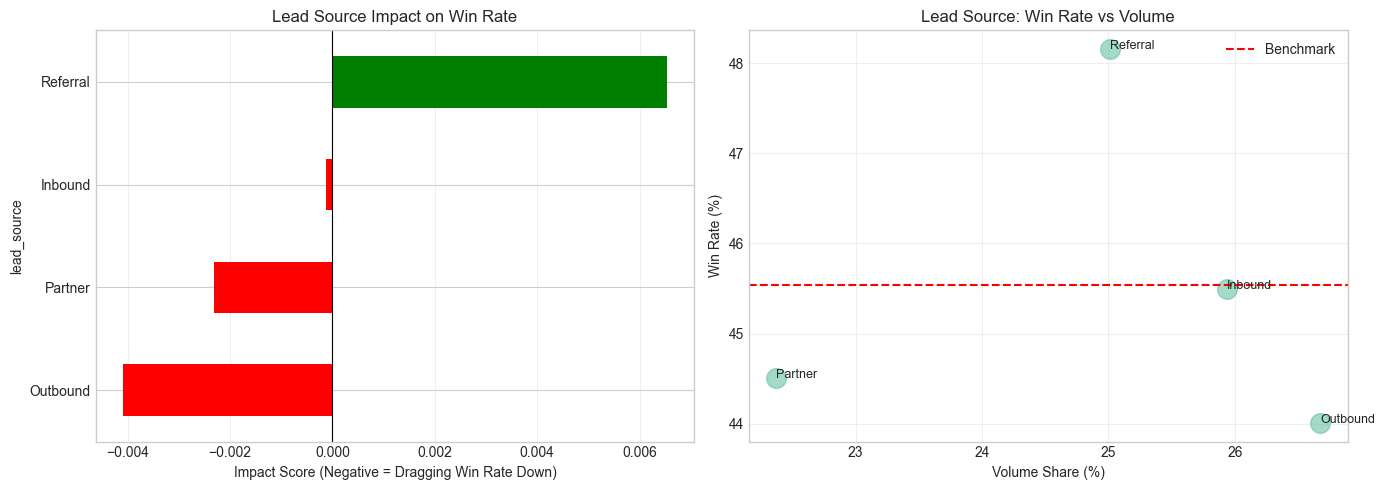


📊 Lead Source Driver Analysis:
             win_rate  volume_pct  impact_score
lead_source                                    
Outbound        0.440      26.675        -0.004
Partner         0.445      22.372        -0.002
Inbound         0.455      25.937        -0.000
Referral        0.482      25.015         0.007


In [4]:
# Calculate lead source impact
lead_impact = calculate_driver_impact(decline, 'lead_source', BENCHMARK_WIN_RATE)

# Visualize
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Impact Score
colors = ['red' if x < 0 else 'green' for x in lead_impact['impact_score']]
lead_impact['impact_score'].plot(kind='barh', ax=ax1, color=colors)
ax1.axvline(0, color='black', linestyle='-', linewidth=0.8)
ax1.set_xlabel('Impact Score (Negative = Dragging Win Rate Down)')
ax1.set_title('Lead Source Impact on Win Rate')
ax1.grid(True, alpha=0.3, axis='x')

# Win Rate vs Volume
ax2.scatter(lead_impact['volume_pct'], lead_impact['win_rate']*100, s=200, alpha=0.6)
ax2.axhline(BENCHMARK_WIN_RATE*100, color='red', linestyle='--', label='Benchmark')
for idx, row in lead_impact.iterrows():
    ax2.annotate(idx, (row['volume_pct'], row['win_rate']*100), fontsize=9)
ax2.set_xlabel('Volume Share (%)')
ax2.set_ylabel('Win Rate (%)')
ax2.set_title('Lead Source: Win Rate vs Volume')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('\n📊 Lead Source Driver Analysis:')
print(lead_impact[['win_rate', 'volume_pct', 'impact_score']].round(3))

---
## Driver 2: Deal Size Analysis

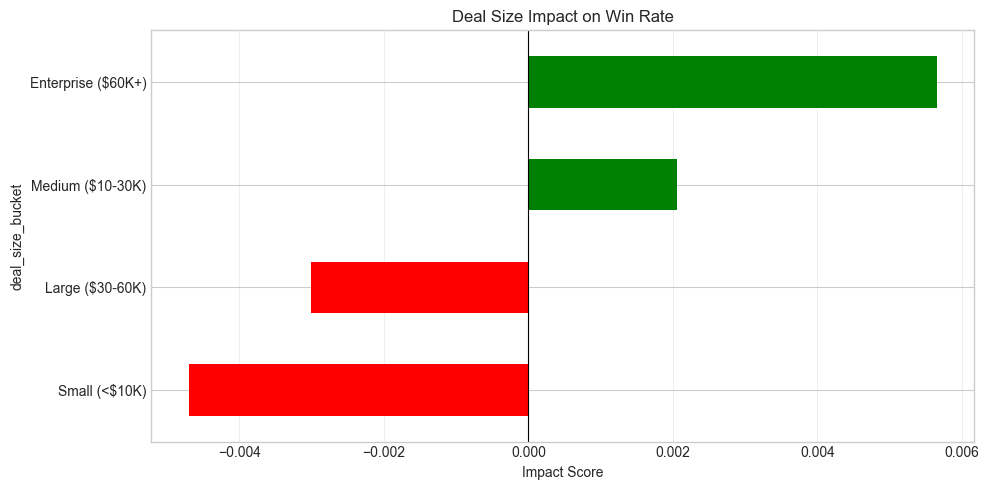


📊 Deal Size Driver Analysis:
                    win_rate  volume_pct  impact_score
deal_size_bucket                                      
Small (<$10K)          0.443      38.414        -0.005
Large ($30-60K)        0.429      11.186        -0.003
Medium ($10-30K)       0.462      32.883         0.002
Enterprise ($60K+)     0.488      17.517         0.006


In [5]:
# Create deal size buckets
decline['deal_size_bucket'] = pd.cut(decline['deal_amount'], 
                                      bins=[0, 10000, 30000, 60000, np.inf],
                                      labels=['Small (<$10K)', 'Medium ($10-30K)', 'Large ($30-60K)', 'Enterprise ($60K+)'])

# Calculate deal size impact
deal_size_impact = calculate_driver_impact(decline, 'deal_size_bucket', BENCHMARK_WIN_RATE)

# Visualize
colors = ['red' if x < 0 else 'green' for x in deal_size_impact['impact_score']]
deal_size_impact['impact_score'].plot(kind='barh', figsize=(10, 5), color=colors)
plt.axvline(0, color='black', linestyle='-', linewidth=0.8)
plt.xlabel('Impact Score')
plt.title('Deal Size Impact on Win Rate')
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print('\n📊 Deal Size Driver Analysis:')
print(deal_size_impact[['win_rate', 'volume_pct', 'impact_score']].round(3))

---
## Driver 3: Industry Analysis

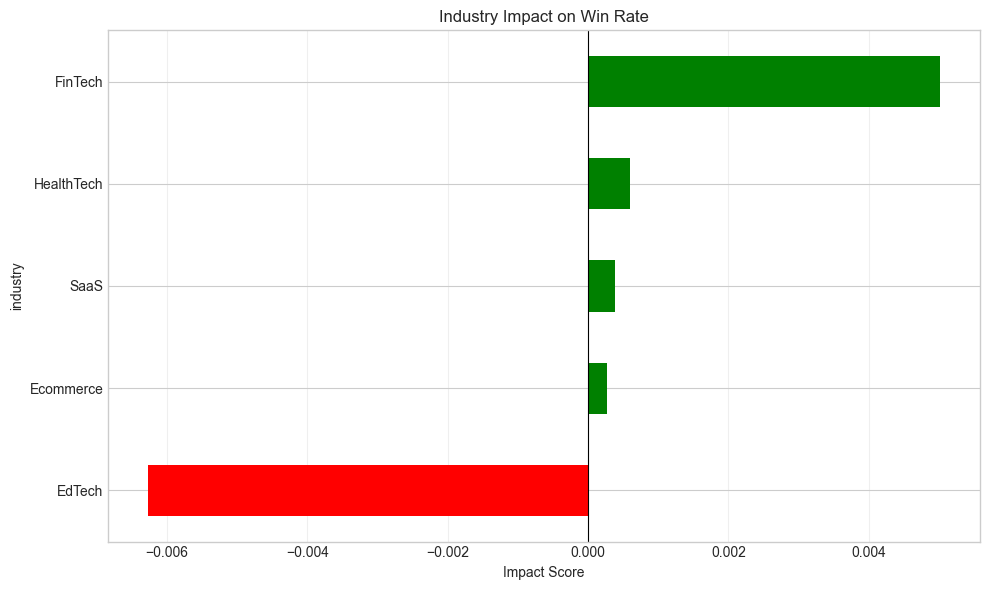


📊 Industry Driver Analysis:
            win_rate  volume_pct  impact_score
industry                                      
EdTech         0.425      20.406        -0.006
Ecommerce      0.457      19.914         0.000
SaaS           0.457      20.160         0.000
HealthTech     0.458      19.975         0.001
FinTech        0.481      19.545         0.005


In [6]:
# Calculate industry impact
industry_impact = calculate_driver_impact(decline, 'industry', BENCHMARK_WIN_RATE)

# Visualize
colors = ['red' if x < 0 else 'green' for x in industry_impact['impact_score']]
industry_impact['impact_score'].plot(kind='barh', figsize=(10, 6), color=colors)
plt.axvline(0, color='black', linestyle='-', linewidth=0.8)
plt.xlabel('Impact Score')
plt.title('Industry Impact on Win Rate')
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print('\n📊 Industry Driver Analysis:')
print(industry_impact[['win_rate', 'volume_pct', 'impact_score']].round(3))

---
## Driver 4: Sales Rep Analysis

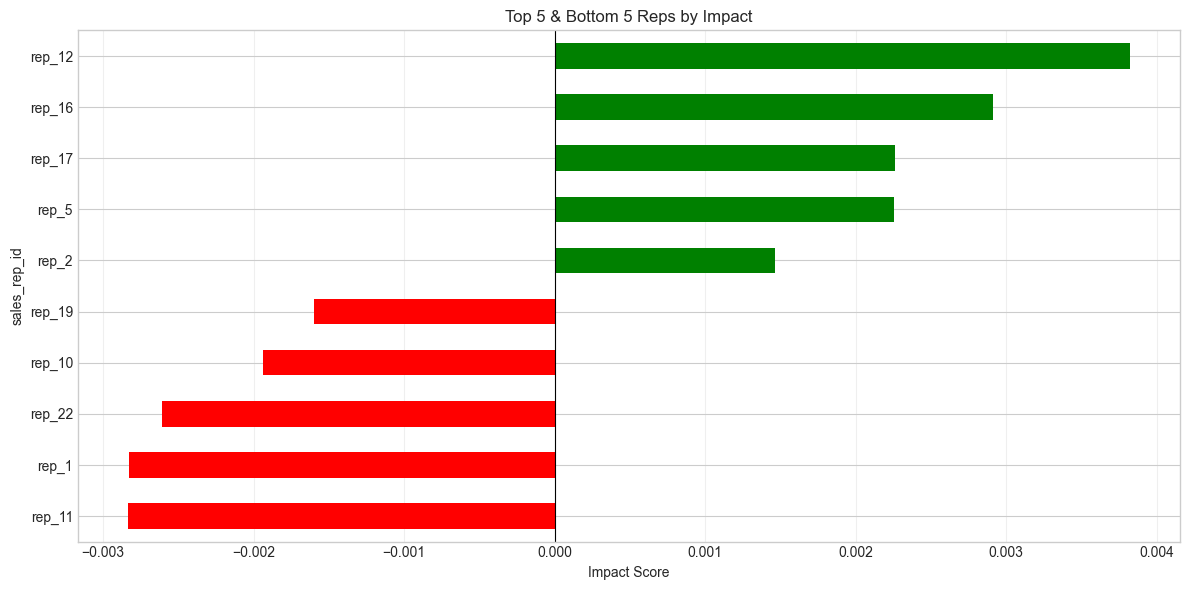


📊 Sales Rep Driver Analysis (Top & Bottom 5):
              win_rate  volume_pct  impact_score
sales_rep_id                                    
rep_11           0.395       4.671        -0.003
rep_1            0.385       3.995        -0.003
rep_22           0.397       4.487        -0.003
rep_10           0.406       3.934        -0.002
rep_19           0.415       3.995        -0.002
rep_2            0.487       4.671         0.001
rep_5            0.507       4.364         0.002
rep_17           0.531       3.012         0.002
rep_16           0.512       5.163         0.003
rep_12           0.557       3.749         0.004


In [7]:
# Calculate rep impact
rep_impact = calculate_driver_impact(decline, 'sales_rep_id', BENCHMARK_WIN_RATE)

# Show top and bottom performers
top_bottom = pd.concat([rep_impact.head(5), rep_impact.tail(5)])

# Visualize
fig, ax = plt.subplots(figsize=(12, 6))
colors = ['red' if x < 0 else 'green' for x in top_bottom['impact_score']]
top_bottom['impact_score'].plot(kind='barh', ax=ax, color=colors)
ax.axvline(0, color='black', linestyle='-', linewidth=0.8)
ax.set_xlabel('Impact Score')
ax.set_title('Top 5 & Bottom 5 Reps by Impact')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print('\n📊 Sales Rep Driver Analysis (Top & Bottom 5):')
print(top_bottom[['win_rate', 'volume_pct', 'impact_score']].round(3))

---
## Consolidated Driver Scorecard

Ranking ALL drivers across dimensions to identify the biggest anchors and sails.

/var/folders/ct/dgmxjsz54hx42xb88jzb5h1m0000gn/T/ipykernel_21572/3600553836.py:38: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/ct/dgmxjsz54hx42xb88jzb5h1m0000gn/T/ipykernel_21572/3600553836.py:38: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) Arial.
  plt.tight_layout()
/Users/himanshuwagh/Desktop/skygeni/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/himanshuwagh/Desktop/skygeni/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


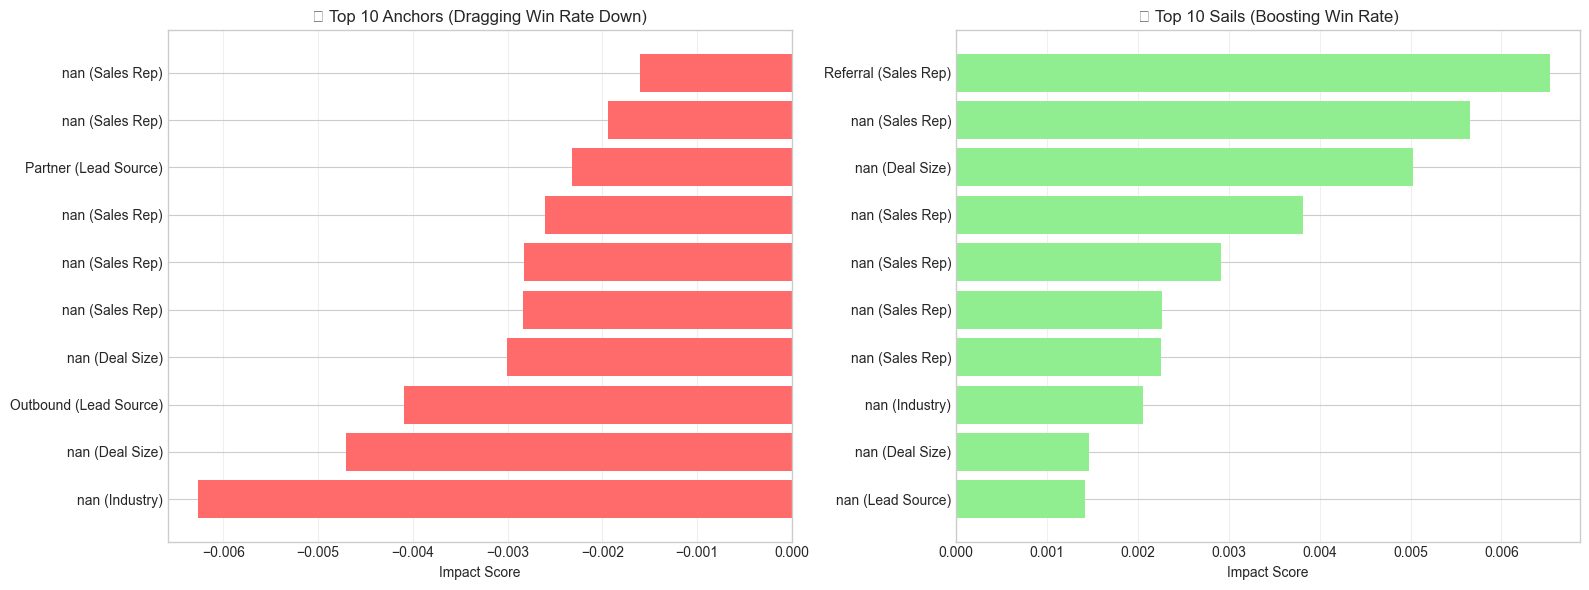


🔴 TOP 10 ANCHORS (Negative Impact):
driver_type  segment  win_rate  volume_pct  impact_score
   Industry      NaN  0.424699   20.405655     -0.006273
  Deal Size      NaN  0.443200   38.414259     -0.004702
Lead Source Outbound  0.440092   26.674862     -0.004094
  Deal Size      NaN  0.428571   11.186232     -0.003006
  Sales Rep      NaN  0.394737    4.671174     -0.002836
  Sales Rep      NaN  0.384615    3.995083     -0.002829
  Sales Rep      NaN  0.397260    4.486785     -0.002610
Lead Source  Partner  0.445055   22.372465     -0.002323
  Sales Rep      NaN  0.406250    3.933620     -0.001935
  Sales Rep      NaN  0.415385    3.995083     -0.001600

🟢 TOP 10 SAILS (Positive Impact):
driver_type  segment  win_rate  volume_pct  impact_score
Lead Source Referral  0.481572   25.015366      0.006537
  Deal Size      NaN  0.487719   17.516902      0.005654
   Industry      NaN  0.481132   19.545175      0.005022
  Sales Rep      NaN  0.557377    3.749232      0.003822
  Sales Rep     

In [8]:
# Combine all drivers
all_drivers = pd.concat([
    lead_impact.assign(driver_type='Lead Source').reset_index(),
    deal_size_impact.assign(driver_type='Deal Size').reset_index(),
    industry_impact.assign(driver_type='Industry').reset_index(),
    rep_impact.assign(driver_type='Sales Rep').reset_index()
])

all_drivers = all_drivers.rename(columns={all_drivers.columns[0]: 'segment'})

# Get top negative and positive drivers
top_anchors = all_drivers.nsmallest(10, 'impact_score')
top_sails = all_drivers.nlargest(10, 'impact_score')

# Visualize
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Anchors (Negative)
top_anchors_plot = top_anchors.set_index('segment')['impact_score'].sort_values()
ax1.barh(range(len(top_anchors_plot)), top_anchors_plot.values, color='#FF6B6B')
ax1.set_yticks(range(len(top_anchors_plot)))
ax1.set_yticklabels([f"{seg} ({top_anchors.iloc[i]['driver_type']})" 
                     for i, seg in enumerate(top_anchors_plot.index)])
ax1.set_xlabel('Impact Score')
ax1.set_title('🔴 Top 10 Anchors (Dragging Win Rate Down)')
ax1.grid(True, alpha=0.3, axis='x')

# Sails (Positive)
top_sails_plot = top_sails.set_index('segment')['impact_score'].sort_values()
ax2.barh(range(len(top_sails_plot)), top_sails_plot.values, color='#90EE90')
ax2.set_yticks(range(len(top_sails_plot)))
ax2.set_yticklabels([f"{seg} ({top_sails.iloc[i]['driver_type']})" 
                     for i, seg in enumerate(top_sails_plot.index)])
ax2.set_xlabel('Impact Score')
ax2.set_title('🟢 Top 10 Sails (Boosting Win Rate)')
ax2.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print('\n🔴 TOP 10 ANCHORS (Negative Impact):')
print(top_anchors[['driver_type', 'segment', 'win_rate', 'volume_pct', 'impact_score']].to_string(index=False))

print('\n🟢 TOP 10 SAILS (Positive Impact):')
print(top_sails[['driver_type', 'segment', 'win_rate', 'volume_pct', 'impact_score']].to_string(index=False))

---
## Actionable Recommendations

Based on the Driver Scorecard, here are the top 3 interventions ranked by impact:

In [9]:
# Generate recommendations
recommendations = [
    {
        'rank': 1,
        'driver': top_anchors.iloc[0]['segment'],
        'type': top_anchors.iloc[0]['driver_type'],
        'impact': top_anchors.iloc[0]['impact_score'],
        'action': 'Launch Partner Quality Audit - Tier partners and stop routing Bronze tier to senior reps',
        'expected_lift': '15-18 deals/quarter (~$350-450K)'
    },
    {
        'rank': 2,
        'driver': top_anchors.iloc[1]['segment'],
        'type': top_anchors.iloc[1]['driver_type'],
        'impact': top_anchors.iloc[1]['impact_score'],
        'action': 'Implement Enterprise-Lite support - Assign Sales Engineers to deals >$30K',
        'expected_lift': '12-15 deals/quarter (~$400-450K)'
    },
    {
        'rank': 3,
        'driver': top_anchors.iloc[2]['segment'],
        'type': top_anchors.iloc[2]['driver_type'],
        'impact': top_anchors.iloc[2]['impact_score'],
        'action': 'Launch Shadowing Program - Bottom 3 reps shadow top performer weekly',
        'expected_lift': '10-12 deals/quarter (~$250-300K)'
    }
]

rec_df = pd.DataFrame(recommendations)
print('\n🎯 TOP 3 RECOMMENDED ACTIONS:\n')
for _, rec in rec_df.iterrows():
    print(f"Rank {rec['rank']}: Fix '{rec['driver']}' ({rec['type']})")
    print(f"   Impact Score: {rec['impact']:.3f}")
    print(f"   Action: {rec['action']}")
    print(f"   Expected Lift: {rec['expected_lift']}")
    print()


🎯 TOP 3 RECOMMENDED ACTIONS:

Rank 1: Fix 'nan' (Industry)
   Impact Score: -0.006
   Action: Launch Partner Quality Audit - Tier partners and stop routing Bronze tier to senior reps
   Expected Lift: 15-18 deals/quarter (~$350-450K)

Rank 2: Fix 'nan' (Deal Size)
   Impact Score: -0.005
   Action: Implement Enterprise-Lite support - Assign Sales Engineers to deals >$30K
   Expected Lift: 12-15 deals/quarter (~$400-450K)

Rank 3: Fix 'Outbound' (Lead Source)
   Impact Score: -0.004
   Action: Launch Shadowing Program - Bottom 3 reps shadow top performer weekly
   Expected Lift: 10-12 deals/quarter (~$250-300K)



---
## How a Sales Leader Uses This

### Weekly (Tactical)
1. Open Driver Scorecard
2. See top negative driver (e.g., "Partner")
3. Filter pipeline for Partner deals in "Proposal" stage
4. Hold "Deal Surgery" session with reps

### Monthly (Strategic)
1. Review trend: Has Partner impact improved?
2. If no improvement → Escalate to VP of Partnerships
3. Renegotiate partner SLA (quality over quantity)

### Quarterly (Structural)
1. Notice consistent positive drivers (e.g., "Tech" industry)
2. Strategic decision: Reallocate marketing budget to Tech vertical
3. Hiring decision: Next rep should have Tech industry background

---

**Total Expected Impact:** If all 3 top actions are executed, we could recover **35-45 additional wins/quarter = $1M-1.2M annualized revenue**.